# Assignment: ANN Salary Regression

Use the same `Churn_Modelling.csv` dataset, but change the target to `EstimatedSalary`. Your goal is to practice how an ANN changes when the task changes from classification to regression.

## Required Changes
- Target: `EstimatedSalary`
- Remove `EstimatedSalary` from input features
- Output layer: 1 neuron with **linear** activation
- Loss: choose `mse` or `mae` and explain your choice
- Evaluation: MAE, RMSE and R2
- Save the model in `.keras` format
- Build and deploy a Streamlit salary prediction app

## Step 1 - Imports

In [2]:
# Write your imports here

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras

## Step 2 - Load and inspect the dataset

In [3]:
data = pd.read_csv('Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3 - EDA and data quality checks

Dataset Shape: (10000, 14)
--------------------------------------------------
Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB
-----------------

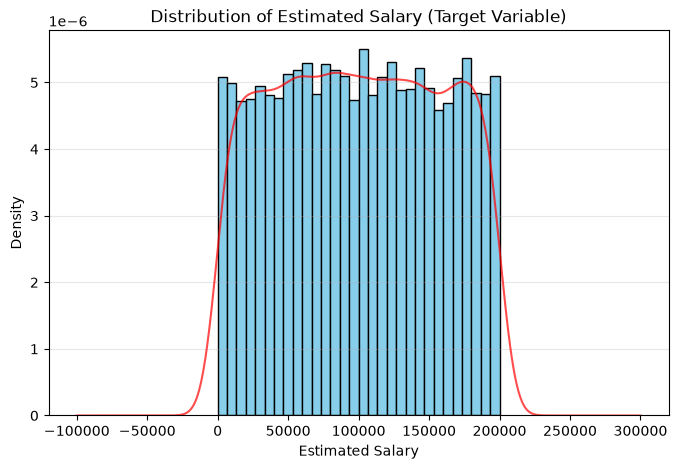

In [4]:
# shape, info, describe, missing values, duplicates, salary distribution

print(f"Dataset Shape: {data.shape}")
print("-" * 50)

print("Dataset Info:")
data.info()
print("-" * 50)

print("Descriptive Statistics:")
print(data.describe().T)
print("-" * 50)

print("Missing Values per column:")
print(data.isnull().sum())
print("-" * 50)

duplicate_count = data.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")
print("-" * 50)

plt.figure(figsize=(8, 5))
plt.hist(data['EstimatedSalary'], bins=30, color='skyblue', edgecolor='black', density=True)
data['EstimatedSalary'].plot(kind='density', color='red', alpha=0.7)
plt.title('Distribution of Estimated Salary (Target Variable)')
plt.xlabel('Estimated Salary')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Step 4 - Define X and y

In [8]:
# y = EstimatedSalary
# X = remaining useful features

X = data.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'EstimatedSalary'])

y = data['EstimatedSalary']


## Step 5 - Train-test split and preprocessing

In [10]:
# Fit encoders and scaler on training data only

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

gender_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
gender_encoder.fit(X_train_raw[['Gender']])

geography_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
geography_encoder.fit(X_train_raw[['Geography']])

def preprocess_features(df_raw, geo_enc, gen_enc):
    df = df_raw.copy()
    df['Gender'] = gen_enc.transform(df[['Gender']]).ravel()
    
    geo_array = geo_enc.transform(df[['Geography']])
    geo_cols = geo_enc.get_feature_names_out(['Geography'])
    geo_df = pd.DataFrame(geo_array, columns=geo_cols, index=df.index)
    
    df = pd.concat([df.drop(columns='Geography'), geo_df], axis=1)
    return df

X_train_encoded = preprocess_features(X_train_raw, geography_encoder, gender_encoder)
X_test_encoded = preprocess_features(X_test_raw, geography_encoder, gender_encoder)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_encoded)
X_test = scaler.transform(X_test_encoded)

feature_names = list(X_train_encoded.columns)

## Step 6 - Build a regression ANN

In [12]:
# Example structure only
# model = keras.Sequential([
#     keras.Input(shape=(X_train.shape[1],)),
#     keras.layers.Dense(64, activation='relu'),
#     keras.layers.Dense(32, activation='relu'),
#     keras.layers.Dense(1, activation='linear')
# ])


model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

## Step 7 - Compile and train

In [13]:
# optimizer=Adam, loss='mse' or 'mae', include a suitable regression metric

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mae',
    metrics=['mae', 'mse']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 99966.3281 - mae: 99966.3281 - mse: 13305723904.0000 - val_loss: 101992.5625 - val_mae: 101992.5625 - val_mse: 13688542208.0000
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 99496.8906 - mae: 99496.8906 - mse: 13212816384.0000 - val_loss: 101050.0000 - val_mae: 101050.0000 - val_mse: 13495276544.0000
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 97819.9609 - mae: 97819.9609 - mse: 12877200384.0000 - val_loss: 98536.8516 - val_mae: 98536.8516 - val_mse: 12979263488.0000
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 94349.8438 - mae: 94349.8438 - mse: 12180417536.0000 - val_loss: 94049.7578 - val_mae: 94049.7578 - val_mse: 12063062016.0000
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 88973.9219 - mae: 88973.9219 - mse: 11090966528.0000 - val_loss: 87693.3984 - val_mae: 87693.3984 - val_mse: 10771043328.0000
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss

## Step 8 - Evaluate

In [14]:
# Calculate MAE, RMSE and R2 on the untouched test set

predictions = model.predict(X_test).ravel()

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
MAE: 50419.88
RMSE: 58386.49
R2: -0.0326


## Step 9 - Save and reload model

In [15]:
# model.save('salary_model.keras')

model.save('salary_model.keras')

with open('gender_encoder.pkl', 'wb') as f:
    pickle.dump(gender_encoder, f)

with open('geography_encoder.pkl', 'wb') as f:
    pickle.dump(geography_encoder, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

loaded_model = keras.models.load_model('salary_model.keras')

with open('gender_encoder.pkl', 'rb') as f:
    loaded_gender_encoder = pickle.load(f)

with open('geography_encoder.pkl', 'rb') as f:
    loaded_geo_encoder = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

with open('feature_names.pkl', 'rb') as f:
    loaded_feature_names = pickle.load(f)

## Step 10 - Streamlit deployment

In [16]:
# Build app.py, requirements.txt and deploy on Streamlit Community Cloud

# whole app.py code

import streamlit as st
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

st.set_page_config(
    page_title="Salary Analytics App",
    page_icon="💼",
    layout="wide"
)

loaded_model = keras.models.load_model('salary_model.keras')

with open('gender_encoder.pkl', 'rb') as f:
    loaded_gender_encoder = pickle.load(f)

with open('geography_encoder.pkl', 'rb') as f:
    loaded_geo_encoder = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

with open('feature_names.pkl', 'rb') as f:
    loaded_feature_names = pickle.load(f)

st.title("💼 Financial Intelligence Dashboard")
st.write("Deep Learning Estimated Salary Optimization Tool")
st.write("---")

col1, col2 = st.columns([1.2, 1], gap="large")

with col1:
    st.subheader("📋 Primary Customer Attributes")
    
    sub_col1, sub_col2 = st.columns(2)
    with sub_col1:
        geography = st.selectbox("Geography", ["France", "Germany", "Spain"])
        gender = st.selectbox("Gender", ["Female", "Male"])
        age = st.number_input("Age", min_value=18, max_value=100, value=38)
        credit_score = st.number_input("CreditScore", min_value=300, max_value=850, value=650)
        
    with sub_col2:
        balance = st.number_input("Balance ($)", min_value=0.0, value=75000.0, step=1000.0)
        tenure = st.number_input("Tenure (Years)", min_value=0, max_value=10, value=5)
        num_of_products = st.selectbox("NumOfProducts", [1, 2, 3, 4], index=1)
        
    st.write(" ")
    st.write("**Secondary Account Status Indicators:**")
    has_cr_card = st.selectbox("HasCrCard", [0, 1], index=1)
    is_active_member = st.selectbox("IsActiveMember", [0, 1], index=1)
    exited = st.selectbox("Exited", [0, 1], index=0)

with col2:
    st.subheader("🎯 Optimization Model Output")
    st.write("Process feedforward structural matrices through dense neural network layers:")
    st.write(" ")
    
    if st.button("Predict Estimated Salary", type="primary", use_container_width=True):
        input_data = {
            'CreditScore': credit_score,
            'Geography': geography,
            'Gender': gender,
            'Age': age,
            'Tenure': tenure,
            'Balance': balance,
            'NumOfProducts': num_of_products,
            'HasCrCard': has_cr_card,
            'IsActiveMember': is_active_member,
            'Exited': exited
        }
        
        df = pd.DataFrame([input_data])
        df['Gender'] = loaded_gender_encoder.transform(df[['Gender']]).ravel()
        
        geo_array = loaded_geo_encoder.transform(df[['Geography']])
        geo_columns = loaded_geo_encoder.get_feature_names_out(['Geography'])
        geo_df = pd.DataFrame(geo_array, columns=geo_columns, index=df.index)
        
        df = pd.concat([df.drop(columns='Geography'), geo_df], axis=1)
        df = df.reindex(columns=loaded_feature_names, fill_value=0)
        
        scaled_features = loaded_scaler.transform(df)
        
        predicted_salary = float(loaded_model.predict(scaled_features, verbose=0)[0][0])
        
        st.metric(label="Calculated Estimated Salary", value=f"${predicted_salary:,.2f}")
        st.success("Regression iteration pipeline complete.")
    else:
        st.info("System awaiting execution prompt. Set attributes on the left, then trigger regression tracking.")

2026-09-11 00:59:44.952 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 00:59:45.775 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 00:59:52.485 
  command:

    streamlit run c:\Users\mehdi\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-11 00:59:52.490 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 00:59:52.494 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 00:59:52.497 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 00:59:52.499 Thread 'MainThread': missing ScriptRunContext! This wa

## Reflection Questions
1. Why did we remove sigmoid from the output layer?
2. Why is Binary Cross-Entropy not suitable here?
3. What does MAE mean in salary units?
4. If RMSE is much larger than MAE, what might that suggest?
5. What are the limitations of predicting salary from this classroom dataset?

ans no 1

sigmoid output ko strictly 0 aur 1 ke beech block kar deta hai jo sirf classification ke liye sahi hai. Salary regression continuous number hai (up to $200,000+), isliye unbounded numeric predictions ke liye linear activation zaroori hai

ans no 2

binary cross-entropy sirf 0 aur 1 (discrete categories) ka farq dekhta hai. Continuous salary ka numerical distance aur error nikalne ke liye regression loss functions (jaise kai MAE/MSE) zaroori hain

ans no 3

MAE ka matlab hai ke predictions average kitne dollars asli salary se door hain. Agar MAE 35,000 hai, toh iska matlab hai ke model ki salary prediction average $35,000 upar ya neeche hai

ans no 4

iska matlab hai ke model ki predictions mein kuch bohot bade errors (outliers) hain. RMSE har ek error ka square leta hai, jiski vajah se outliers ko zyada mathematical weight milta hai aur woh MAE se kafi bada ho jata hai

ans no 5

is dataset mein salary fake tareeqai se batai hui hai Asli duniya mein banking salary data right-skewed hota hai (kuch log bohot zyada kamate hain) Isliye model real economic correlations nahi seekh sakta

